# Mask vs. Delete Ablation Comparison

This notebook compares **masking** and **deletion** for five span sources:

- Random spans
- LLM spans
- Attention spans
- SHAP spans
- MIL spans

The selected information is kept fixed within each method. Existing masking probabilities are reused, while only the missing deletion probabilities are computed.

The notebook preserves the previous evaluation logic: test true positives are used, repeated random samples are aggregated at argument level, the model input format is validated against stored masking scores, and mask/delete effects are compared using descriptive summaries, bootstrap confidence intervals, paired statistics, and plots.

## Evaluation design and important assumptions

- The LLM file contains test-set true positives. The other result files are therefore restricted to test true positives as well.
- Mask and delete are evaluated on **the same already-selected content**.
- The deletion condition is constructed directly from each method's existing `masked_text`: every `[MASK]` token is removed and only resulting whitespace artifacts are cleaned. This avoids method-specific character-offset parsing and guarantees that the delete condition corresponds to the same selected tokens as the mask condition.
- Existing masking probabilities are reused. The classifier is run only for newly generated deleted texts.
- If random spans contain several `sample_id` repetitions for one argument, row-level results are retained, but primary summaries and statistical tests aggregate them by `global_row_id`.
- The model input format is inferred by comparing recomputed masking probabilities against the stored masking probabilities. Review the reported mean absolute error before interpreting deletion results.
- Probability drop is defined as:

$$
\Delta p =
p(\mathrm{inappropriate}\mid x)
-
p(\mathrm{inappropriate}\mid x_{\mathrm{perturbed}})
$$

A positive value means that making the selected information unavailable reduced the model's inappropriateness score.

In [1]:
from __future__ import annotations

import math
import re
import warnings
from pathlib import Path
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

try:
    from scipy.stats import wilcoxon
except ImportError:
    wilcoxon = None
    warnings.warn("scipy is not installed. Wilcoxon tests will be skipped.")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
# -----------------------------------------------------------------------------
# Paths and evaluation configuration
# -----------------------------------------------------------------------------
BASE_DIR = Path.cwd().parent

RANDOM_RESULTS_PATH = BASE_DIR / "results/random_baseline_results/random_best_config_test_per_argument.csv"
LLM_RESULTS_PATH = BASE_DIR / "results/llm_reference/llm_test_tp_spans_argument_level.csv"
ATTENTION_RESULTS_PATH = BASE_DIR / "results/attention_results/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_argument_level.csv"
SHAP_RESULTS_PATH = BASE_DIR / "results/shap_results/shap_results_final/shap_final_test_q0.5_window0_argument_level.csv"
MIL_RESULTS_PATH = BASE_DIR / "results/mil_results/mil_span_run_singles/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=3__spans=15__stride=4__freeze=True_argument_level.csv"

OUTPUT_DIR = BASE_DIR / "results/ablation_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME_OR_PATH = "timonziegenbein/appropriateness-classifier-binary"
INAPPROPRIATE_LABEL_ID = 1

BATCH_SIZE = 32
MAX_LENGTH = 512
PREDICTION_THRESHOLD = 0.5

FILTER_RANDOM_TO_TEST_TP = True
FILTER_LLM_TO_VALID_ROWS = True

# The stored masked texts were produced for the DeBERTa-based classifier.
MASK_TOKEN = "[MASK]"

# Clean only whitespace/punctuation artifacts created by removing mask tokens.
NORMALIZE_DELETED_WHITESPACE = True

# "auto" tests several common input formats against stored masking scores.
MODEL_INPUT_MODE = "auto"
AUTO_INPUT_MODE_CANDIDATES = [
    "pair_issue_argument",
    "argument_only",
    "concat_issue_argument",
]
AUTO_MODE_SAMPLE_SIZE = 64

N_BOOTSTRAP = 2_000

print(f"Random input:    {RANDOM_RESULTS_PATH}")
print(f"LLM input:       {LLM_RESULTS_PATH}")
print(f"Attention input: {ATTENTION_RESULTS_PATH}")
print(f"SHAP input:      {SHAP_RESULTS_PATH}")
print(f"MIL input:       {MIL_RESULTS_PATH}")
print(f"Output dir:      {OUTPUT_DIR}")

Random input:    /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results/random_best_config_test_per_argument.csv
LLM input:       /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/llm_reference/llm_test_tp_spans_argument_level.csv
Attention input: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_argument_level.csv
SHAP input:      /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/shap_results/shap_results_final/shap_final_test_q0.5_window0_argument_level.csv
MIL input:       /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/mil_results/mil_span_run_singles/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=3__spans=15__stride=4__freeze=True_argument_level.csv
Output dir:      /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/

In [3]:
# Load the existing result files.
df_random_raw = pd.read_csv(RANDOM_RESULTS_PATH)
df_llm_raw = pd.read_csv(LLM_RESULTS_PATH)
df_attention_raw = pd.read_csv(ATTENTION_RESULTS_PATH)
df_shap_raw = pd.read_csv(SHAP_RESULTS_PATH)
df_mil_raw = pd.read_csv(MIL_RESULTS_PATH)

print("Random results shape:   ", df_random_raw.shape)
print("LLM results shape:      ", df_llm_raw.shape)
print("Attention results shape:", df_attention_raw.shape)
print("SHAP results shape:     ", df_shap_raw.shape)
print("MIL results shape:      ", df_mil_raw.shape)

Random results shape:    (438, 54)
LLM results shape:       (100, 37)
Attention results shape: (438, 43)
SHAP results shape:      (438, 49)
MIL results shape:       (2191, 50)


## 1. Prepare comparable masking rows

The random result file may contain an `ablation_mode` column, so masking rows are retained explicitly when present. All methods are restricted to the test split and true-positive classifier cases. LLM validity filtering is applied only when the corresponding validity columns exist.

In [4]:
def as_bool(series: pd.Series) -> pd.Series:
    """Convert common string/numeric boolean encodings to Boolean values."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .isin({"true", "1", "yes", "y", "t"})
    )


def filter_random_mask_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Retain the random masking rows used for the test-TP comparison."""
    out = df.copy()

    if "ablation_mode" in out.columns:
        mask_rows = out["ablation_mode"].astype(str).str.lower().eq("mask")
        if mask_rows.any():
            out = out.loc[mask_rows].copy()
        else:
            warnings.warn(
                "No rows with ablation_mode='mask' were found. All rows are retained."
            )

    if "split" in out.columns:
        out = out.loc[out["split"].astype(str).str.lower().eq("test")].copy()

    if FILTER_RANDOM_TO_TEST_TP:
        if "confusion_type" in out.columns:
            out = out.loc[
                out["confusion_type"].astype(str).str.upper().eq("TP")
            ].copy()
        elif "is_true_positive" in out.columns:
            out = out.loc[as_bool(out["is_true_positive"])].copy()
        else:
            warnings.warn(
                "No TP indicator was found in the random file. No TP filter was applied."
            )

    return out.reset_index(drop=True)


def filter_test_tp_rows(
    df: pd.DataFrame,
    apply_llm_validity_filter: bool = False,
) -> pd.DataFrame:
    """Retain test true positives; optionally require valid LLM annotations."""
    out = df.copy()

    if "split" in out.columns:
        out = out.loc[out["split"].astype(str).str.lower().eq("test")].copy()

    if apply_llm_validity_filter and FILTER_LLM_TO_VALID_ROWS:
        if "llm_valid_bool" in out.columns:
            out = out.loc[as_bool(out["llm_valid_bool"])].copy()
        elif "llm_valid" in out.columns:
            out = out.loc[as_bool(out["llm_valid"])].copy()

    if "confusion_type" in out.columns:
        is_tp = out["confusion_type"].astype(str).str.upper().eq("TP")
        if is_tp.any():
            out = out.loc[is_tp].copy()

    return out.reset_index(drop=True)


df_random = filter_random_mask_rows(df_random_raw)
df_llm = filter_test_tp_rows(df_llm_raw, apply_llm_validity_filter=True)
df_attention = filter_test_tp_rows(df_attention_raw)
df_shap = filter_test_tp_rows(df_shap_raw)
df_mil = filter_test_tp_rows(df_mil_raw)

print("Filtered random rows:   ", len(df_random))
print("Filtered LLM rows:      ", len(df_llm))
print("Filtered Attention rows:", len(df_attention))
print("Filtered SHAP rows:     ", len(df_shap))
print("Filtered MIL rows:      ", len(df_mil))

print()
print("Unique arguments:")
for name, frame in [
    ("Random spans", df_random),
    ("LLM spans", df_llm),
    ("Attention spans", df_attention),
    ("SHAP spans", df_shap),
    ("MIL spans", df_mil),
]:
    print(f"{name:16s}: {frame['global_row_id'].nunique()}")

random_counts = df_random.groupby("global_row_id").size()
print("\nRandom rows per argument:")
display(random_counts.describe().to_frame("rows_per_argument"))

# Common argument set across all five methods.
id_sets = [
    set(frame["global_row_id"].dropna())
    for frame in (df_random, df_llm, df_attention, df_shap, df_mil)
]
common_ids = sorted(set.intersection(*id_sets)) if id_sets else []
print(f"Arguments available in all five methods: {len(common_ids)}")

Filtered random rows:    186
Filtered LLM rows:       100
Filtered Attention rows: 186
Filtered SHAP rows:      186
Filtered MIL rows:       186

Unique arguments:
Random spans    : 186
LLM spans       : 100
Attention spans : 186
SHAP spans      : 186
MIL spans       : 186

Random rows per argument:


,rows_per_argument
count,186.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


Arguments available in all five methods: 100


## 2. Construct deletion inputs from the existing masked texts

The previous version attempted to reconstruct deletion spans from method-specific character offsets. That works for Random and LLM results but fails for Attention, SHAP, and MIL because those files do not contain the LLM offset columns.

Here, deletion is derived from the already available `masked_text` for every method. This preserves the selected content exactly at the perturbation level:

- **Mask condition:** keep the stored `masked_text`.
- **Delete condition:** remove all `[MASK]` tokens from that same text.

Only whitespace and punctuation spacing introduced by the removal is cleaned. Rows without any mask token are reported and excluded because they do not define a meaningful mask/delete comparison. Entirely deleted arguments are **not** removed; they are valid cases where the selected content covers the full argument.

In [5]:
def clean_deleted_text(text: str) -> str:
    """Clean only whitespace artifacts created by mask-token deletion."""
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"\s+([,.;:!?])", r"\1", text)
    text = re.sub(r"([\(\[\{])\s+", r"\1", text)
    return text


def delete_from_masked_text(
    masked_text: str,
    mask_token: str = MASK_TOKEN,
    normalize_whitespace: bool = True,
) -> str:
    """Remove mask tokens from an existing masked text."""
    if pd.isna(masked_text):
        return ""

    deleted = str(masked_text).replace(mask_token, " ")
    if normalize_whitespace:
        deleted = clean_deleted_text(deleted)
    return deleted


def count_mask_tokens(masked_text: str, mask_token: str = MASK_TOKEN) -> int:
    """Count selected model tokens represented by mask tokens."""
    if pd.isna(masked_text):
        return 0
    return str(masked_text).count(mask_token)


def count_mask_groups(masked_text: str, mask_token: str = MASK_TOKEN) -> int:
    """Count contiguous groups of mask tokens as approximate selected spans."""
    if pd.isna(masked_text):
        return 0

    token = re.escape(mask_token)
    pattern = rf"{token}(?:\s+{token})*"
    return len(re.findall(pattern, str(masked_text)))


def prepare_method_frame(
    df: pd.DataFrame,
    method_name: str,
    argument_column: str,
) -> pd.DataFrame:
    """Standardize one method and construct its deletion condition."""
    out = df.copy()
    out["method"] = method_name
    out["argument"] = out[argument_column].fillna("").astype(str)
    out["masked_text"] = out["masked_text"].fillna("").astype(str)

    out["n_mask_tokens_existing"] = out["masked_text"].map(count_mask_tokens)
    out["n_delete_spans"] = out["masked_text"].map(count_mask_groups)

    out["deleted_text"] = out["masked_text"].map(
        lambda text: delete_from_masked_text(
            text,
            mask_token=MASK_TOKEN,
            normalize_whitespace=NORMALIZE_DELETED_WHITESPACE,
        )
    )

    # Keep the same descriptive character-ratio field used downstream.
    # It is derived from the actual original-vs-deleted text lengths.
    out["deleted_chars"] = (
        out["argument"].str.len() - out["deleted_text"].str.len()
    ).clip(lower=0)
    out["deleted_char_ratio"] = np.where(
        out["argument"].str.len().gt(0),
        out["deleted_chars"] / out["argument"].str.len(),
        np.nan,
    )

    return out


random_work = prepare_method_frame(df_random, "Random spans", "text")
llm_work = prepare_method_frame(df_llm, "LLM spans", "argument")
attention_work = prepare_method_frame(df_attention, "Attention spans", "text")
shap_work = prepare_method_frame(df_shap, "SHAP spans", "text")
mil_work = prepare_method_frame(df_mil, "MIL spans", "text")

work_frames = {
    "Random spans": random_work,
    "LLM spans": llm_work,
    "Attention spans": attention_work,
    "SHAP spans": shap_work,
    "MIL spans": mil_work,
}

span_validation = pd.DataFrame(
    [
        {
            "method": method,
            "rows": len(frame),
            "rows_without_valid_span": int(
                frame["n_mask_tokens_existing"].eq(0).sum()
            ),
            "empty_deleted_texts": int(
                frame["deleted_text"].str.len().eq(0).sum()
            ),
        }
        for method, frame in work_frames.items()
    ]
)

display(span_validation)

# Rows without any mask token do not define a mask/delete comparison.
for method, frame in list(work_frames.items()):
    work_frames[method] = (
        frame.loc[frame["n_mask_tokens_existing"].gt(0)]
        .reset_index(drop=True)
    )

random_work = work_frames["Random spans"]
llm_work = work_frames["LLM spans"]
attention_work = work_frames["Attention spans"]
shap_work = work_frames["SHAP spans"]
mil_work = work_frames["MIL spans"]

print("Rows retained after mask-token validation:")
for method, frame in work_frames.items():
    print(f"{method:16s}: {len(frame)}")

# Recompute the common set after validation so the common-argument analysis
# truly contains rows available for all five methods.
validated_id_sets = [
    set(frame["global_row_id"].dropna())
    for frame in work_frames.values()
]
common_ids = (
    sorted(set.intersection(*validated_id_sets))
    if validated_id_sets
    else []
)
print(f"Validated arguments available in all five methods: {len(common_ids)}")


,method,rows,rows_without_valid_span,empty_deleted_texts
0,Random spans,186,0,40
1,LLM spans,100,0,7
2,Attention spans,186,0,0
3,SHAP spans,186,0,0
4,MIL spans,186,0,36


Rows retained after mask-token validation:
Random spans    : 186
LLM spans       : 100
Attention spans : 186
SHAP spans      : 186
MIL spans       : 186
Validated arguments available in all five methods: 100


In [6]:
# Inspect a few mask/delete examples before running the classifier.
def show_deletion_examples(frame: pd.DataFrame, n: int = 3) -> None:
    columns = [
        "global_row_id",
        "issue",
        "argument",
        "masked_text",
        "deleted_text",
        "n_mask_tokens_existing",
        "n_delete_spans",
        "deleted_char_ratio",
    ]
    display(frame[columns].head(n))


for method, frame in work_frames.items():
    print(f"\n{method} deletion examples")
    show_deletion_examples(frame)


Random spans deletion examples


,global_row_id,issue,argument,masked_text,deleted_text,n_mask_tokens_existing,n_delete_spans,deleted_char_ratio
0,1754,Tv is better than books:,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [M...,,27,1,1.000000
1,1755,Tv is better than books:,"Books enlighten the soul. Books don't destroy the morals of children. Books throw the mind into a series of questions, they take the readers to mystical pla...",Books [MASK] the [MASK] [MASK] Books [MASK] [MASK] [MASK] destroy [MASK] morals [MASK] children. Books [MASK] the [MASK] into a series [MASK] [MASK] [MASK] ...,"Books the Books destroy morals children. Books the into a series they take to mystical places, paradise, even the sink. They change your perspective on life...",36,21,0.351852
2,1756,India has the potential to lead the world:,india is is good adopter but a bad developer and leader should be a great developer,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK],,16,1,1.000000



LLM spans deletion examples


,global_row_id,issue,argument,masked_text,deleted_text,n_mask_tokens_existing,n_delete_spans,deleted_char_ratio
0,1754,Tv is better than books:,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,I [MASK] that book are better than TV is it is better i can put you in a whole [MASK] and it is educational,I that book are better than TV is it is better i can put you in a whole and it is educational,2,2,0.169643
1,1756,India has the potential to lead the world:,india is is good adopter but a bad developer and leader should be a great developer,[MASK],,1,1,1.000000
2,1759,Evolution vs creation:,"I am a nurse and the more I studied biology, the more I was in awe of the miracle of our bodies. Every tiny cell has it's own design that is even more compl...","I am a nurse and the more I studied biology, the more I was in awe of the miracle of our bodies. Every tiny cell has it's own design that is even more compl...","I am a nurse and the more I studied biology, the more I was in awe of the miracle of our bodies. Every tiny cell has it's own design that is even more compl...",1,1,0.116945



Attention spans deletion examples


,global_row_id,issue,argument,masked_text,deleted_text,n_mask_tokens_existing,n_delete_spans,deleted_char_ratio
0,1754,Tv is better than books:,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,[MASK] [MASK] [MASK] [MASK] [MASK] better than TV [MASK] [MASK] [MASK] better [MASK] can put [MASK] [MASK] [MASK] whole norther wold [MASK] [MASK] [MASK] [M...,better than TV better can put whole norther wold,16,5,0.571429
1,1755,Tv is better than books:,"Books enlighten the soul. Books don't destroy the morals of children. Books throw the mind into a series of questions, they take the readers to mystical pla...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] don[MASK]t destroy [MASK] [MASK] [MASK] children[MASK] Books throw [MASK] mind into [MASK] [MASK] [MASK] questions...,don t destroy children Books throw mind into questions take mystical places paradise even kitchen sink change perspective life often give reader sense like ...,58,26,0.462963
2,1756,India has the potential to lead the world:,india is is good adopter but a bad developer and leader should be a great developer,[MASK] [MASK] [MASK] good adopter [MASK] [MASK] bad developer [MASK] leader [MASK] [MASK] [MASK] great [MASK],good adopter bad developer leader great,10,5,0.530120



SHAP spans deletion examples


,global_row_id,issue,argument,masked_text,deleted_text,n_mask_tokens_existing,n_delete_spans,deleted_char_ratio
0,1754,Tv is better than books:,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,[MASK] [MASK] that book are [MASK] [MASK] [MASK] is it is [MASK] [MASK] can put [MASK] [MASK] [MASK] whole [MASK] [MASK] wold and it [MASK] [MASK],that book are is it is can put whole wold and it,14,6,0.571429
1,1755,Tv is better than books:,"Books enlighten the soul. Books don't destroy the morals of children. Books throw the mind into a series of questions, they take the readers to mystical pla...","[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] don't [MASK] [MASK] [MASK] [MASK] [MASK]. [MASK] throw the mind into a series of questions, they take the readers ...","don't. throw the mind into a series of questions, they take the readers to mystical places, paradise, and. They change your perspective on life and often gi...",30,5,0.331019
2,1756,India has the potential to lead the world:,india is is good adopter but a bad developer and leader should be a great developer,[MASK] is is [MASK] adopter but a [MASK] [MASK] [MASK] leader [MASK] [MASK] a great developer,is is adopter but a leader a great developer,7,4,0.469880



MIL spans deletion examples


,global_row_id,issue,argument,masked_text,deleted_text,n_mask_tokens_existing,n_delete_spans,deleted_char_ratio
0,1754,Tv is better than books:,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,I thick that book [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK...,I thick that book,21,1,0.848214
1,1755,Tv is better than books:,"Books enlighten the soul. Books don't destroy the morals of children. Books throw the mind into a series of questions, they take the readers to mystical pla...","Books enlighten the soul. Books don't destroy the morals of children. Books throw the mind into a series of questions, they take the readers to mystical pla...","Books enlighten the soul. Books don't destroy the morals of children. Books throw the mind into a series of questions, they take the readers to mystical pla...",27,1,0.354167
2,1756,India has the potential to lead the world:,india is is good adopter but a bad developer and leader should be a great developer,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK],,16,1,1.000000


## 3. Load the classifier and reproduce the stored masking scores

Before scoring deleted texts, the notebook checks which input construction best reproduces the existing masked probabilities. A large mismatch usually indicates one of the following:

- a different classifier checkpoint,
- a different inappropriate-class index,
- a different issue/argument input format,
- different truncation or preprocessing settings.

The selected mode and its mean absolute error are printed below. Ideally, the error should be close to zero apart from small floating-point differences.

In [7]:
# Select GPU when available, otherwise MPS or CPU.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_OR_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_OR_PATH)
model.to(device)
model.eval()

print("Tokenizer mask token:", tokenizer.mask_token)
print("Model labels:", model.config.id2label)
print("Inappropriate label index:", INAPPROPRIATE_LABEL_ID)

if tokenizer.mask_token is not None and tokenizer.mask_token != MASK_TOKEN:
    warnings.warn(
        f"Configured MASK_TOKEN={MASK_TOKEN!r}, but tokenizer.mask_token="
        f"{tokenizer.mask_token!r}. Check how the stored masked_text was created."
    )

Device: mps


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Tokenizer mask token: [MASK]
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}
Inappropriate label index: 1


In [8]:
def tokenize_inputs(
    issues: Sequence[str],
    texts: Sequence[str],
    input_mode: str,
) -> dict[str, torch.Tensor]:
    """Tokenize model inputs using one of the supported input constructions."""
    issues = ["" if pd.isna(x) else str(x) for x in issues]
    texts = ["" if pd.isna(x) else str(x) for x in texts]

    common_kwargs = dict(
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    if input_mode == "pair_issue_argument":
        return tokenizer(issues, texts, **common_kwargs)

    if input_mode == "argument_only":
        return tokenizer(texts, **common_kwargs)

    if input_mode == "concat_issue_argument":
        separator = tokenizer.sep_token or "[SEP]"
        combined = [
            f"{issue} {separator} {text}".strip()
            for issue, text in zip(issues, texts)
        ]
        return tokenizer(combined, **common_kwargs)

    raise ValueError(f"Unknown input mode: {input_mode}")


@torch.inference_mode()
def predict_inappropriate_probability(
    issues: Sequence[str],
    texts: Sequence[str],
    input_mode: str,
    batch_size: int = BATCH_SIZE,
    show_progress: bool = True,
) -> np.ndarray:
    """Return p(inappropriate) for each issue/text input."""
    if len(issues) != len(texts):
        raise ValueError("issues and texts must have the same length")

    probabilities: list[np.ndarray] = []
    iterator = range(0, len(texts), batch_size)
    if show_progress:
        iterator = tqdm(iterator, total=math.ceil(len(texts) / batch_size))

    for start in iterator:
        end = min(start + batch_size, len(texts))
        encoded = tokenize_inputs(
            issues[start:end],
            texts[start:end],
            input_mode=input_mode,
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}

        logits = model(**encoded).logits
        probs = torch.softmax(logits, dim=-1)[:, INAPPROPRIATE_LABEL_ID]
        probabilities.append(probs.detach().cpu().numpy())

    if not probabilities:
        return np.array([], dtype=float)

    return np.concatenate(probabilities)

In [9]:
def stored_mask_probability(frame: pd.DataFrame) -> pd.Series:
    """Select the stored masking probability from known column variants."""
    candidates = [
        "p_inappropriate_masked",
        "p_inappropriate_perturbed",
    ]
    available = [column for column in candidates if column in frame.columns]
    if not available:
        raise KeyError(
            f"None of the expected masking probability columns exists: {candidates}"
        )

    result = pd.to_numeric(frame[available[0]], errors="coerce")
    for column in available[1:]:
        result = result.fillna(pd.to_numeric(frame[column], errors="coerce"))
    return result


for frame in work_frames.values():
    frame["p_inappropriate_masked_existing"] = stored_mask_probability(frame)

# Keep the same input-mode validation logic as before: use balanced samples
# from Random and LLM results.
validation_parts = []
for frame in (random_work, llm_work):
    valid = frame.loc[
        frame["p_inappropriate_masked_existing"].notna()
        & frame["masked_text"].notna()
    ].copy()

    if len(valid) > 0:
        validation_parts.append(
            valid.sample(
                n=min(len(valid), AUTO_MODE_SAMPLE_SIZE // 2),
                random_state=RANDOM_SEED,
            )
        )

if not validation_parts:
    raise RuntimeError("No rows are available for model input-mode validation.")

validation_df = pd.concat(validation_parts, ignore_index=True)
print("Rows used for input-mode validation:", len(validation_df))


def evaluate_input_mode(input_mode: str) -> dict[str, float | str | int]:
    predicted = predict_inappropriate_probability(
        validation_df["issue"].fillna("").astype(str).tolist(),
        validation_df["masked_text"].fillna("").astype(str).tolist(),
        input_mode=input_mode,
        show_progress=False,
    )

    stored = validation_df["p_inappropriate_masked_existing"].to_numpy(dtype=float)
    absolute_error = np.abs(predicted - stored)

    return {
        "input_mode": input_mode,
        "n": len(stored),
        "mae": float(np.nanmean(absolute_error)),
        "median_absolute_error": float(np.nanmedian(absolute_error)),
        "max_absolute_error": float(np.nanmax(absolute_error)),
        "correlation": float(pd.Series(predicted).corr(pd.Series(stored))),
    }


if MODEL_INPUT_MODE == "auto":
    mode_results = pd.DataFrame(
        [evaluate_input_mode(mode) for mode in AUTO_INPUT_MODE_CANDIDATES]
    ).sort_values("mae")
    display(mode_results)
    selected_input_mode = str(mode_results.iloc[0]["input_mode"])
else:
    selected_input_mode = MODEL_INPUT_MODE
    mode_results = pd.DataFrame([evaluate_input_mode(selected_input_mode)])
    display(mode_results)

print("Selected model input mode:", selected_input_mode)

best_mae = float(mode_results.sort_values("mae").iloc[0]["mae"])
if best_mae > 0.01:
    warnings.warn(
        "The stored masking probabilities were not reproduced closely "
        f"(best MAE={best_mae:.4f}). Check the checkpoint, label index, "
        "input construction, preprocessing, and MAX_LENGTH before interpreting "
        "the deletion comparison."
    )

Rows used for input-mode validation: 64


,input_mode,n,mae,median_absolute_error,max_absolute_error,correlation
1,argument_only,64,1.088483e-08,1.110223e-16,2.384186e-07,1.000000
0,pair_issue_argument,64,1.456899e-01,6.781518e-04,9.780416e-01,0.208852
2,concat_issue_argument,64,1.456899e-01,6.781518e-04,9.780416e-01,0.208852


Selected model input mode: argument_only


## 4. Score the deleted texts

The original and masked probabilities are taken from the existing result files. For each row, the notebook computes:

- `p_inappropriate_deleted`
- `predicted_label_deleted`
- `prob_drop_delete`
- `positive_drop_delete`
- `prediction_flip_delete`

The corresponding masking columns are standardized to the same naming scheme.

In [124]:
def score_deleted_texts(frame: pd.DataFrame, method_name: str) -> pd.DataFrame:
    out = frame.copy()
    print(f"Scoring deleted texts for {method_name}: {len(out)} rows")

    out["p_inappropriate_deleted"] = predict_inappropriate_probability(
        out["issue"].fillna("").astype(str).tolist(),
        out["deleted_text"].fillna("").astype(str).tolist(),
        input_mode=selected_input_mode,
    )

    out["p_inappropriate_original"] = pd.to_numeric(
        out["p_inappropriate_original"], errors="coerce"
    )
    out["p_inappropriate_masked_existing"] = pd.to_numeric(
        out["p_inappropriate_masked_existing"], errors="coerce"
    )

    out["prob_drop_mask"] = (
        out["p_inappropriate_original"]
        - out["p_inappropriate_masked_existing"]
    )
    out["prob_drop_delete"] = (
        out["p_inappropriate_original"]
        - out["p_inappropriate_deleted"]
    )

    out["positive_drop_mask"] = out["prob_drop_mask"].gt(0)
    out["positive_drop_delete"] = out["prob_drop_delete"].gt(0)

    out["predicted_label_original_derived"] = (
        out["p_inappropriate_original"].ge(PREDICTION_THRESHOLD).astype(int)
    )
    out["predicted_label_mask_derived"] = (
        out["p_inappropriate_masked_existing"].ge(PREDICTION_THRESHOLD).astype(int)
    )
    out["predicted_label_deleted"] = (
        out["p_inappropriate_deleted"].ge(PREDICTION_THRESHOLD).astype(int)
    )

    # A flip is counted when an originally inappropriate prediction becomes appropriate.
    out["prediction_flip_mask"] = (
        out["predicted_label_original_derived"].eq(1)
        & out["predicted_label_mask_derived"].eq(0)
    )
    out["prediction_flip_delete"] = (
        out["predicted_label_original_derived"].eq(1)
        & out["predicted_label_deleted"].eq(0)
    )

    out["delete_minus_mask_prob_drop"] = (
        out["prob_drop_delete"] - out["prob_drop_mask"]
    )
    out["delete_better_than_mask"] = out["delete_minus_mask_prob_drop"].gt(0)

    return out


random_scored = score_deleted_texts(random_work, "Random spans")
llm_scored = score_deleted_texts(llm_work, "LLM spans")
attention_scored = score_deleted_texts(attention_work, "Attention spans")
shap_scored = score_deleted_texts(shap_work, "SHAP spans")
mil_scored = score_deleted_texts(mil_work, "MIL spans")

scored_frames = {
    "Random spans": random_scored,
    "LLM spans": llm_scored,
    "Attention spans": attention_scored,
    "SHAP spans": shap_scored,
    "MIL spans": mil_scored,
}

Scoring deleted texts for Random spans: 186 rows


  0%|          | 0/6 [00:00<?, ?it/s]

Scoring deleted texts for LLM spans: 100 rows


  0%|          | 0/4 [00:00<?, ?it/s]

Scoring deleted texts for Attention spans: 186 rows


  0%|          | 0/6 [00:00<?, ?it/s]

Scoring deleted texts for SHAP spans: 186 rows


  0%|          | 0/6 [00:00<?, ?it/s]

Scoring deleted texts for MIL spans: 186 rows


  0%|          | 0/6 [00:00<?, ?it/s]

In [125]:
# Sanity checks for probability-drop consistency.
def probability_sanity_checks(
    frame: pd.DataFrame,
    method_name: str,
) -> pd.DataFrame:
    if "prob_drop" in frame.columns:
        stored_drop = pd.to_numeric(frame["prob_drop"], errors="coerce")
    else:
        stored_drop = pd.Series(np.nan, index=frame.index, dtype=float)

    recomputed_drop = frame["prob_drop_mask"]

    return pd.DataFrame(
        {
            "method": [method_name],
            "rows": [len(frame)],
            "missing_original_probability": [
                int(frame["p_inappropriate_original"].isna().sum())
            ],
            "missing_mask_probability": [
                int(frame["p_inappropriate_masked_existing"].isna().sum())
            ],
            "missing_delete_probability": [
                int(frame["p_inappropriate_deleted"].isna().sum())
            ],
            "stored_vs_recomputed_mask_drop_mae": [
                float(np.nanmean(np.abs(stored_drop - recomputed_drop)))
                if stored_drop.notna().any()
                else np.nan
            ],
            "mean_original_probability": [
                float(frame["p_inappropriate_original"].mean())
            ],
            "mean_mask_probability": [
                float(frame["p_inappropriate_masked_existing"].mean())
            ],
            "mean_delete_probability": [
                float(frame["p_inappropriate_deleted"].mean())
            ],
        }
    )


sanity_table = pd.concat(
    [
        probability_sanity_checks(frame, method)
        for method, frame in scored_frames.items()
    ],
    ignore_index=True,
)
display(sanity_table)

,method,rows,missing_original_probability,missing_mask_probability,missing_delete_probability,stored_vs_recomputed_mask_drop_mae,mean_original_probability,mean_mask_probability,mean_delete_probability
0,Random spans,186,0,0,0,8.432401e-17,0.981553,0.853876,0.863543
1,LLM spans,100,0,0,0,5.669469e-17,0.987367,0.871350,0.860549
2,Attention spans,186,0,0,0,7.689398e-17,0.981553,0.744211,0.989411
3,SHAP spans,186,0,0,0,8.878596e-17,0.981555,0.778823,0.782774
4,MIL spans,186,0,0,0,8.582533e-17,0.981555,0.828519,0.790140


## 5. Convert results to a common long format

The long table contains one row per method, argument/sample, and ablation mode. It is used for plotting and exporting. The selected-token ratio is identical for mask and delete because the selected content does not change.

In [127]:
def first_existing_numeric(
    frame: pd.DataFrame,
    columns: Sequence[str],
) -> pd.Series:
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    for column in columns:
        if column in frame.columns:
            result = result.fillna(pd.to_numeric(frame[column], errors="coerce"))
    return result


def make_long_results(
    frame: pd.DataFrame,
    method_name: str,
) -> pd.DataFrame:    
    base = pd.DataFrame(index=frame.index)
    base["method"] = method_name
    base["global_row_id"] = frame["global_row_id"].values
    base["post_id"] = frame["post_id"].values if "post_id" in frame else np.nan
    base["split"] = frame["split"].values if "split" in frame else "test"
    base["confusion_type"] = (
        frame["confusion_type"].values if "confusion_type" in frame else "TP"
    )
    base["sample_id"] = frame["sample_id"].values if "sample_id" in frame else 0
    base["issue"] = frame["issue"].values
    base["argument"] = frame["argument"].values
    base["n_spans"] = frame["n_delete_spans"].values
    base["selected_token_ratio"] = first_existing_numeric(
        frame,
        ["masked_token_ratio", "selected_token_ratio"],
    ).values
    base["deleted_char_ratio"] = frame["deleted_char_ratio"].values
    base["p_inappropriate_original"] = frame["p_inappropriate_original"].values

    mask = base.copy()
    mask["ablation_mode"] = "mask"
    mask["p_inappropriate_perturbed"] = (
        frame["p_inappropriate_masked_existing"].values
    )
    mask["prob_drop"] = frame["prob_drop_mask"].values
    mask["positive_drop"] = frame["positive_drop_mask"].values
    mask["prediction_flip"] = frame["prediction_flip_mask"].values
    mask["perturbed_text"] = frame["masked_text"].values

    delete = base.copy()
    delete["ablation_mode"] = "delete"
    delete["p_inappropriate_perturbed"] = frame["p_inappropriate_deleted"].values
    delete["prob_drop"] = frame["prob_drop_delete"].values
    delete["positive_drop"] = frame["positive_drop_delete"].values
    delete["prediction_flip"] = frame["prediction_flip_delete"].values
    delete["perturbed_text"] = frame["deleted_text"].values

    return pd.concat([mask, delete], ignore_index=True)


results_long_raw = pd.concat(
    [
        make_long_results(random_scored, "Random spans"),
        make_long_results(llm_scored, "LLM spans"),
        make_long_results(attention_scored, "Attention spans"),
        make_long_results(shap_scored, "SHAP spans"),
        make_long_results(mil_scored, "MIL spans"),
    ],
    ignore_index=True,
)

print("Long-format row-level results:", results_long_raw.shape)
display(results_long_raw.head())

Long-format row-level results: (1688, 18)


,method,global_row_id,post_id,split,confusion_type,sample_id,issue,argument,n_spans,selected_token_ratio,deleted_char_ratio,p_inappropriate_original,ablation_mode,p_inappropriate_perturbed,prob_drop,positive_drop,prediction_flip,perturbed_text
0,Random spans,1754,8,test,TP,0,Tv is better than books:,I thick that book are better than TV is it is better i can put you in a whole norther wold and it is educational,1,1.000000,1.000000,0.997475,mask,0.382378,0.615098,True,True,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [M...
1,Random spans,1755,9,test,TP,0,Tv is better than books:,"Books enlighten the soul. Books don't destroy the morals of children. Books throw the mind into a series of questions, they take the readers to mystical pla...",21,0.375000,0.351852,0.998255,mask,0.997191,0.001064,True,False,Books [MASK] the [MASK] [MASK] Books [MASK] [MASK] [MASK] destroy [MASK] morals [MASK] children. Books [MASK] the [MASK] into a series [MASK] [MASK] [MASK] ...
2,Random spans,1756,12,test,TP,0,India has the potential to lead the world:,india is is good adopter but a bad developer and leader should be a great developer,1,1.000000,1.000000,0.995627,mask,0.434695,0.560932,True,True,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]
3,Random spans,1758,18,test,TP,0,William farquhar ought to be honoured as the rightful founder of singapore:,Raffles had written his discovery wrongly as 29 February 1819.It was later corrected. He thought he had discovered Singapore on his firs journey,1,1.000000,1.000000,0.962886,mask,0.382378,0.580508,True,True,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [M...
4,Random spans,1759,22,test,TP,0,Evolution vs creation:,"I am a nurse and the more I studied biology, the more I was in awe of the miracle of our bodies. Every tiny cell has it's own design that is even more compl...",16,0.340659,0.355609,0.992263,mask,0.995645,-0.003382,False,False,I am a [MASK] and [MASK] more I [MASK] [MASK] [MASK] the more I [MASK] in awe [MASK] the [MASK] of our bodies. Every [MASK] cell [MASK] [MASK] [MASK] [MASK]...


## 6. Primary argument-level summaries

For random spans, repeated samples are averaged within each argument and ablation mode. The other methods normally remain unchanged when they contain one row per argument. The resulting table is the primary unit for summaries, confidence intervals, plots, and paired tests.

In [128]:
ARGUMENT_GROUP_COLUMNS = [
    "method",
    "global_row_id",
    "ablation_mode",
]

results_argument_level = (
    results_long_raw
    .groupby(ARGUMENT_GROUP_COLUMNS, as_index=False)
    .agg(
        n_rows=("prob_drop", "size"),
        p_inappropriate_original=("p_inappropriate_original", "mean"),
        p_inappropriate_perturbed=("p_inappropriate_perturbed", "mean"),
        prob_drop=("prob_drop", "mean"),
        positive_drop=("positive_drop", "mean"),
        prediction_flip=("prediction_flip", "mean"),
        selected_token_ratio=("selected_token_ratio", "mean"),
        deleted_char_ratio=("deleted_char_ratio", "mean"),
        n_spans=("n_spans", "mean"),
    )
)

# After averaging repeated random samples, binary indicators become proportions.
print("Argument-level results:", results_argument_level.shape)
display(results_argument_level.head())

Argument-level results: (1688, 12)


,method,global_row_id,ablation_mode,n_rows,p_inappropriate_original,p_inappropriate_perturbed,prob_drop,positive_drop,prediction_flip,selected_token_ratio,deleted_char_ratio,n_spans
0,Attention spans,1754,delete,1,0.997475,0.997120,0.000356,1.0,0.0,0.592593,0.571429,5.0
1,Attention spans,1754,mask,1,0.997475,0.972825,0.024650,1.0,0.0,0.592593,0.571429,5.0
2,Attention spans,1755,delete,1,0.998255,0.997396,0.000859,1.0,0.0,0.604167,0.462963,26.0
3,Attention spans,1755,mask,1,0.998255,0.419498,0.578757,1.0,1.0,0.604167,0.462963,26.0
4,Attention spans,1756,delete,1,0.995627,0.994145,0.001482,1.0,0.0,0.625000,0.530120,5.0


In [129]:
def bootstrap_mean_ci(
    values: Sequence[float],
    n_bootstrap: int = N_BOOTSTRAP,
    confidence: float = 0.95,
    seed: int = RANDOM_SEED,
) -> tuple[float, float]:
    """Non-parametric bootstrap confidence interval for the mean."""
    array = np.asarray(values, dtype=float)
    array = array[np.isfinite(array)]

    if len(array) == 0:
        return np.nan, np.nan
    if len(array) == 1:
        return float(array[0]), float(array[0])

    local_rng = np.random.default_rng(seed)
    indices = local_rng.integers(0, len(array), size=(n_bootstrap, len(array)))
    bootstrap_means = array[indices].mean(axis=1)

    alpha = (1.0 - confidence) / 2.0
    return (
        float(np.quantile(bootstrap_means, alpha)),
        float(np.quantile(bootstrap_means, 1.0 - alpha)),
    )


def summarize_group(group: pd.DataFrame) -> pd.Series:
    prob_drop = group["prob_drop"].dropna().to_numpy()
    ci_low, ci_high = bootstrap_mean_ci(prob_drop)

    return pd.Series(
        {
            "n_arguments": group["global_row_id"].nunique(),
            "mean_p_inappropriate_original": group[
                "p_inappropriate_original"
            ].mean(),
            "mean_p_inappropriate_perturbed": group[
                "p_inappropriate_perturbed"
            ].mean(),
            "mean_prob_drop": group["prob_drop"].mean(),
            "std_prob_drop": group["prob_drop"].std(ddof=1),
            "median_prob_drop": group["prob_drop"].median(),
            "q25_prob_drop": group["prob_drop"].quantile(0.25),
            "q75_prob_drop": group["prob_drop"].quantile(0.75),
            "mean_prob_drop_ci95_low": ci_low,
            "mean_prob_drop_ci95_high": ci_high,
            "positive_drop_rate": group["positive_drop"].mean(),
            "prediction_flip_rate": group["prediction_flip"].mean(),
            "mean_selected_token_ratio": group["selected_token_ratio"].mean(),
            "mean_deleted_char_ratio": group["deleted_char_ratio"].mean(),
            "mean_n_spans": group["n_spans"].mean(),
        }
    )


summary_argument_level = (
    results_argument_level
    .groupby(["method", "ablation_mode"], sort=False)
    .apply(summarize_group)
    .reset_index()
)

display(summary_argument_level.round(4))

,method,ablation_mode,n_arguments,mean_p_inappropriate_original,mean_p_inappropriate_perturbed,mean_prob_drop,std_prob_drop,median_prob_drop,q25_prob_drop,q75_prob_drop,mean_prob_drop_ci95_low,mean_prob_drop_ci95_high,positive_drop_rate,prediction_flip_rate,mean_selected_token_ratio,mean_deleted_char_ratio,mean_n_spans
0,Attention spans,delete,186.0,0.9816,0.9894,-0.0079,0.0675,0.0006,-0.0004,0.0014,-0.0175,0.0017,0.6774,0.0054,0.6000,0.4970,18.4516
1,Attention spans,mask,186.0,0.9816,0.7442,0.2373,0.2501,0.1342,0.0146,0.5258,0.2011,0.2747,0.9624,0.2957,0.6000,0.4970,18.4516
2,LLM spans,delete,100.0,0.9874,0.8605,0.1168,0.2879,-0.0098,-0.0102,-0.0076,0.0634,0.1745,0.6400,0.1700,0.2716,0.2708,1.9600
3,LLM spans,mask,100.0,0.9874,0.8713,0.1160,0.2745,0.0002,-0.0001,0.0020,0.0650,0.1713,0.6900,0.1600,0.2716,0.2708,1.9600
4,MIL spans,delete,186.0,0.9816,0.7901,0.1614,0.3033,-0.0295,-0.0301,0.5510,0.1195,0.2065,0.6452,0.2957,0.5574,0.5544,1.4839
5,MIL spans,mask,186.0,0.9816,0.8285,0.1530,0.2714,0.0006,0.0001,0.3396,0.1151,0.1918,0.7796,0.2581,0.5574,0.5544,1.4839
6,Random spans,delete,186.0,0.9816,0.8635,0.1180,0.2500,0.0004,-0.0001,0.0057,0.0841,0.1550,0.6989,0.2258,0.5008,0.5016,13.0108
7,Random spans,mask,186.0,0.9816,0.8539,0.1277,0.2535,0.0008,0.0003,0.0791,0.0929,0.1650,0.8333,0.2366,0.5008,0.5016,13.0108
8,SHAP spans,delete,186.0,0.9816,0.7828,0.1988,0.3487,0.0017,0.0001,0.2989,0.1474,0.2495,0.7903,0.2204,0.4145,0.4271,7.7043
9,SHAP spans,mask,186.0,0.9816,0.7788,0.2027,0.3382,0.0067,0.0018,0.2770,0.1562,0.2522,0.9516,0.2366,0.4145,0.4271,7.7043


## 7. Paired mask-vs-delete comparison

The paired comparison uses one mask value and one delete value per argument. The key quantity is:

$$
\Delta_{D-M} = \Delta p_{\mathrm{delete}} - \Delta p_{\mathrm{mask}}
$$

- Positive values favor deletion.
- Negative values favor masking.
- The bootstrap interval quantifies uncertainty in the mean paired difference.
- The Wilcoxon signed-rank test evaluates whether the paired differences are systematically shifted away from zero without assuming normally distributed differences.

Statistical significance should not be interpreted as practical relevance on its own. The magnitude and consistency of the difference are more important for choosing an ablation strategy.

In [130]:
def signed_rank_biserial(differences: np.ndarray) -> float:
    """Rank-biserial effect size for paired differences, ignoring exact ties."""
    differences = differences[np.isfinite(differences)]
    differences = differences[differences != 0]

    if len(differences) == 0:
        return np.nan

    ranks = pd.Series(np.abs(differences)).rank(method="average").to_numpy()
    positive_rank_sum = ranks[differences > 0].sum()
    negative_rank_sum = ranks[differences < 0].sum()
    denominator = positive_rank_sum + negative_rank_sum

    return float((positive_rank_sum - negative_rank_sum) / denominator)


def paired_statistics(group: pd.DataFrame) -> pd.Series:
    pivot = group.pivot(
        index="global_row_id",
        columns="ablation_mode",
        values="prob_drop",
    ).dropna(subset=["mask", "delete"])

    mask = pivot["mask"].to_numpy(dtype=float)
    delete = pivot["delete"].to_numpy(dtype=float)
    difference = delete - mask
    ci_low, ci_high = bootstrap_mean_ci(difference)

    if wilcoxon is not None and len(difference) > 0 and np.any(difference != 0):
        test = wilcoxon(
            delete,
            mask,
            alternative="two-sided",
            zero_method="wilcox",
        )
        wilcoxon_statistic = float(test.statistic)
        wilcoxon_p_value = float(test.pvalue)
    else:
        wilcoxon_statistic = np.nan
        wilcoxon_p_value = np.nan

    tolerance = 1e-12

    return pd.Series(
        {
            "n_paired_arguments": len(pivot),
            "mean_prob_drop_mask": float(np.mean(mask)),
            "mean_prob_drop_delete": float(np.mean(delete)),
            "mean_delete_minus_mask": float(np.mean(difference)),
            "mean_difference_ci95_low": ci_low,
            "mean_difference_ci95_high": ci_high,
            "median_delete_minus_mask": float(np.median(difference)),
            "std_delete_minus_mask": (
                float(np.std(difference, ddof=1))
                if len(difference) > 1
                else np.nan
            ),
            "delete_win_rate": float(np.mean(difference > tolerance)),
            "mask_win_rate": float(np.mean(difference < -tolerance)),
            "tie_rate": float(np.mean(np.abs(difference) <= tolerance)),
            "rank_biserial_effect": signed_rank_biserial(difference),
            "wilcoxon_statistic": wilcoxon_statistic,
            "wilcoxon_p_value": wilcoxon_p_value,
        }
    )


paired_summary = (
    results_argument_level
    .groupby("method", sort=False)
    .apply(paired_statistics)
    .reset_index()
)

display(paired_summary.round(4))

,method,n_paired_arguments,mean_prob_drop_mask,mean_prob_drop_delete,mean_delete_minus_mask,mean_difference_ci95_low,mean_difference_ci95_high,median_delete_minus_mask,std_delete_minus_mask,delete_win_rate,mask_win_rate,tie_rate,rank_biserial_effect,wilcoxon_statistic,wilcoxon_p_value
0,Attention spans,186.0,0.2373,-0.0079,-0.2452,-0.2833,-0.2084,-0.1375,0.2583,0.0430,0.9570,0.0,-0.9355,561.0,0.0000
1,LLM spans,100.0,0.1160,0.1168,0.0008,-0.0106,0.0209,-0.0100,0.0942,0.1200,0.8800,0.0,-0.6345,923.0,0.0000
2,MIL spans,186.0,0.1530,0.1614,0.0084,-0.0107,0.0299,-0.0301,0.1423,0.1989,0.8011,0.0,-0.5566,3856.0,0.0000
3,Random spans,186.0,0.1277,0.1180,-0.0097,-0.0183,-0.0027,-0.0005,0.0553,0.2688,0.7312,0.0,-0.4966,4377.0,0.0000
4,SHAP spans,186.0,0.2027,0.1988,-0.0040,-0.0403,0.0316,-0.0012,0.2521,0.3280,0.6720,0.0,-0.1639,7270.0,0.0525


## 8. Visual evaluation

The figures emphasize complementary aspects:

1. Mean probability drop with bootstrap confidence intervals.
2. Positive-drop rate.
3. Full probability-drop distributions.
4. Paired mask/delete scatter plots.
5. Distribution of the paired delete-minus-mask difference.

Because the methods may cover different numbers of arguments, paired plots should primarily be interpreted within each method. A separate common-argument analysis follows below.

In [131]:
METHOD_ORDER = [
    "Random spans",
    "LLM spans",
    "Attention spans",
    "SHAP spans",
    "MIL spans",
]
ABLATION_ORDER = ["mask", "delete"]


def save_current_figure(filename: str) -> None:
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/mean_probability_drop_mask_vs_delete.png


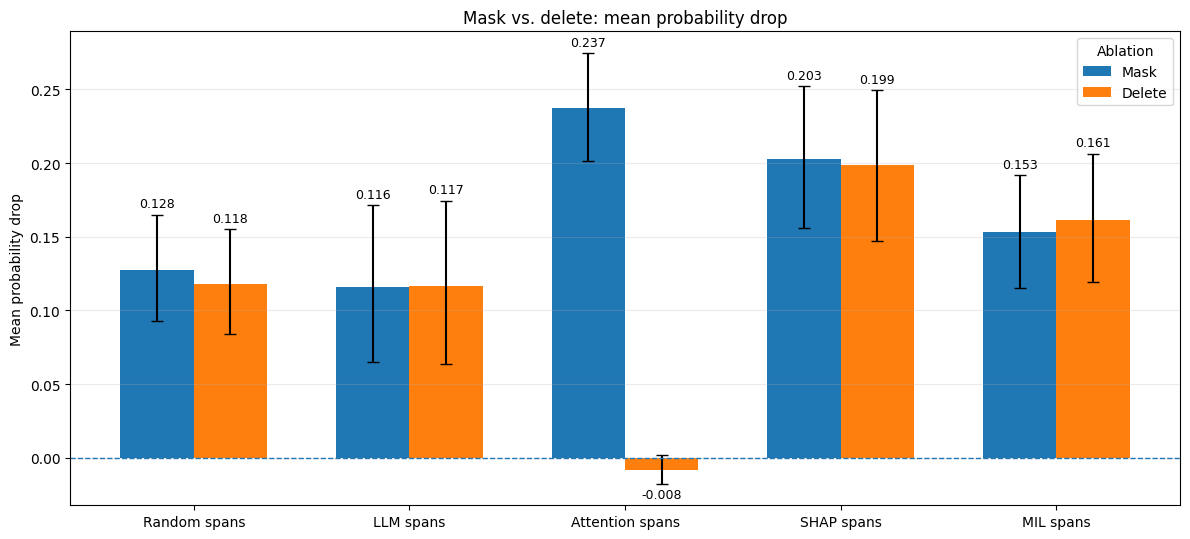

In [132]:
# Plot 1: Mean probability drop with 95% bootstrap confidence intervals.
plot_df = summary_argument_level.copy()

x = np.arange(len(METHOD_ORDER), dtype=float)
width = 0.34

fig, ax = plt.subplots(figsize=(12, 5.5))

for offset_index, ablation_mode in enumerate(ABLATION_ORDER):
    subset = (
        plot_df.loc[plot_df["ablation_mode"].eq(ablation_mode)]
        .set_index("method")
        .reindex(METHOD_ORDER)
    )

    means = subset["mean_prob_drop"].to_numpy(dtype=float)
    lower = means - subset["mean_prob_drop_ci95_low"].to_numpy(dtype=float)
    upper = subset["mean_prob_drop_ci95_high"].to_numpy(dtype=float) - means
    positions = x + (offset_index - 0.5) * width

    bars = ax.bar(
        positions,
        means,
        width=width,
        yerr=np.vstack([lower, upper]),
        capsize=4,
        label=ablation_mode.capitalize(),
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.axhline(0, linewidth=1, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER)
ax.set_ylabel("Mean probability drop")
ax.set_title("Mask vs. delete: mean probability drop")
ax.legend(title="Ablation")
ax.grid(axis="y", alpha=0.25)

save_current_figure("mean_probability_drop_mask_vs_delete.png")
plt.show()

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/positive_drop_rate_mask_vs_delete.png


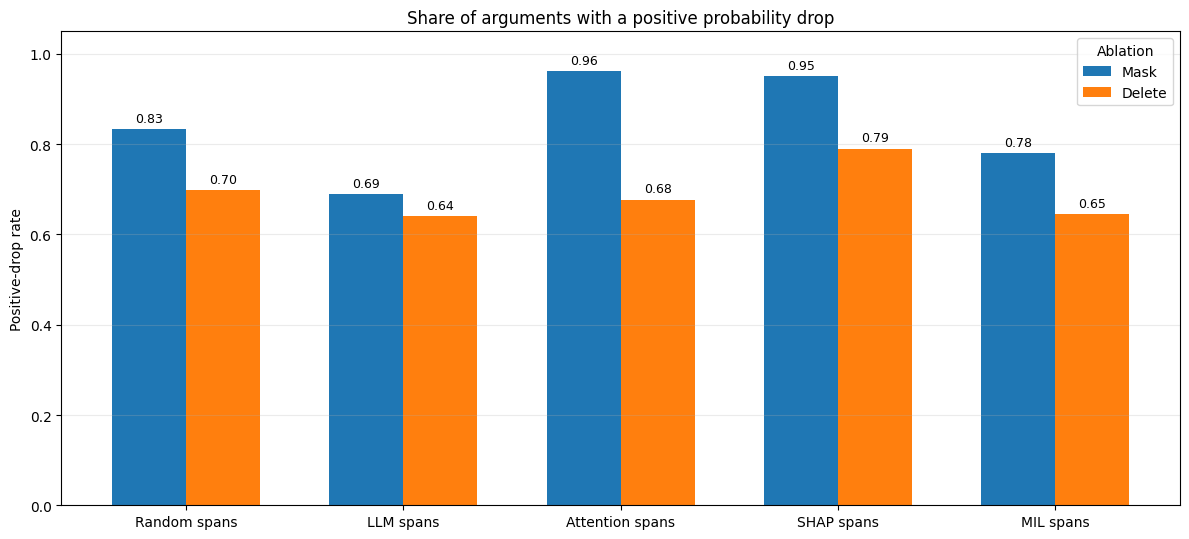

In [133]:
# Plot 2: Positive-drop rate.
plot_df = summary_argument_level.copy()

x = np.arange(len(METHOD_ORDER), dtype=float)
width = 0.34

fig, ax = plt.subplots(figsize=(12, 5.5))

for offset_index, ablation_mode in enumerate(ABLATION_ORDER):
    subset = (
        plot_df.loc[plot_df["ablation_mode"].eq(ablation_mode)]
        .set_index("method")
        .reindex(METHOD_ORDER)
    )

    values = subset["positive_drop_rate"].to_numpy(dtype=float)
    positions = x + (offset_index - 0.5) * width

    bars = ax.bar(
        positions,
        values,
        width=width,
        label=ablation_mode.capitalize(),
    )
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)

ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER)
ax.set_ylabel("Positive-drop rate")
ax.set_title("Share of arguments with a positive probability drop")
ax.legend(title="Ablation")
ax.grid(axis="y", alpha=0.25)

save_current_figure("positive_drop_rate_mask_vs_delete.png")
plt.show()

/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_20014/2193692282.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/probability_drop_boxplots.png


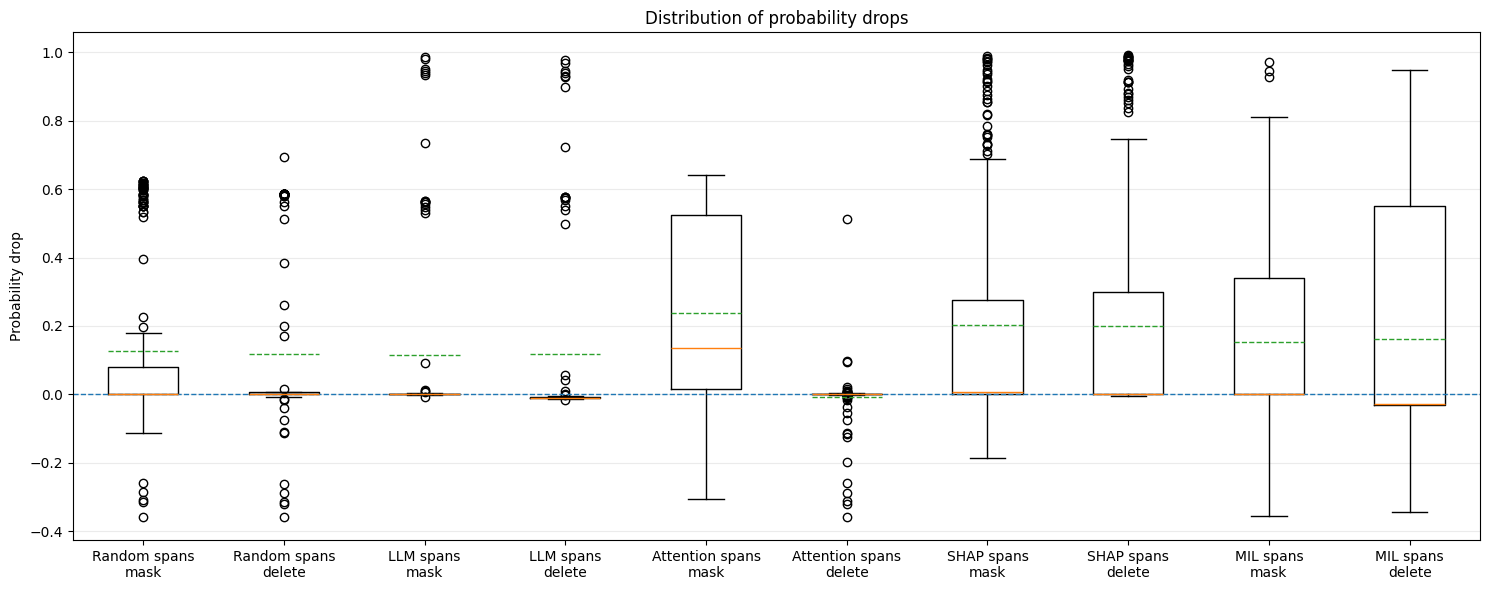

In [134]:
# Plot 3: Probability-drop distributions at argument level.
labels = []
values = []

for method in METHOD_ORDER:
    for ablation_mode in ABLATION_ORDER:
        subset = results_argument_level.loc[
            results_argument_level["method"].eq(method)
            & results_argument_level["ablation_mode"].eq(ablation_mode),
            "prob_drop",
        ].dropna()

        labels.append(f"{method}\n{ablation_mode}")
        values.append(subset.to_numpy())

fig, ax = plt.subplots(figsize=(15, 6))

ax.boxplot(
    values,
    labels=labels,
    showmeans=True,
    meanline=True,
    showfliers=True,
)

ax.axhline(0, linewidth=1, linestyle="--")
ax.set_ylabel("Probability drop")
ax.set_title("Distribution of probability drops")
ax.grid(axis="y", alpha=0.25)

save_current_figure("probability_drop_boxplots.png")
plt.show()

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/paired_scatter_random_spans.png


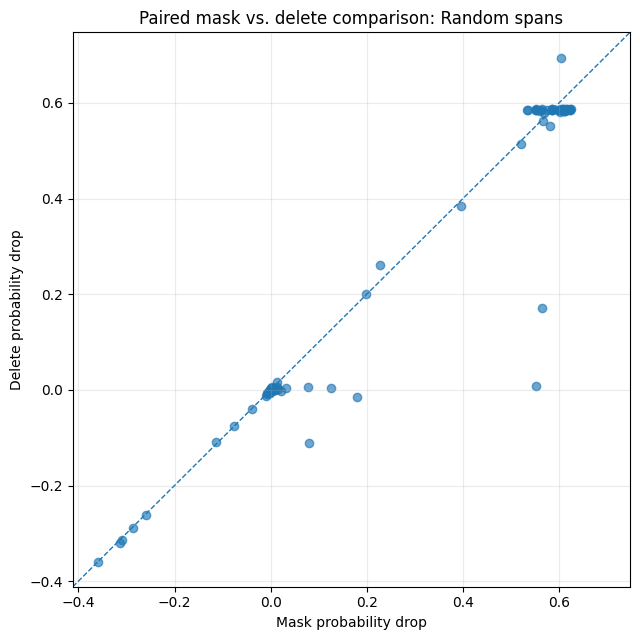

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/paired_scatter_llm_spans.png


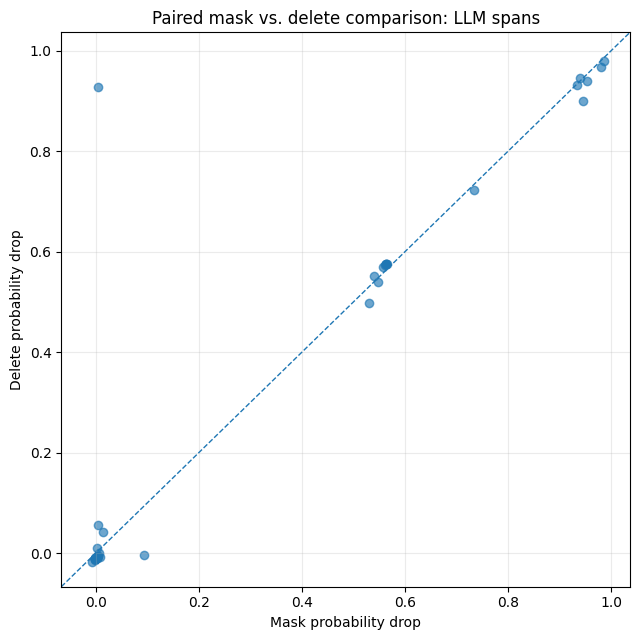

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/paired_scatter_attention_spans.png


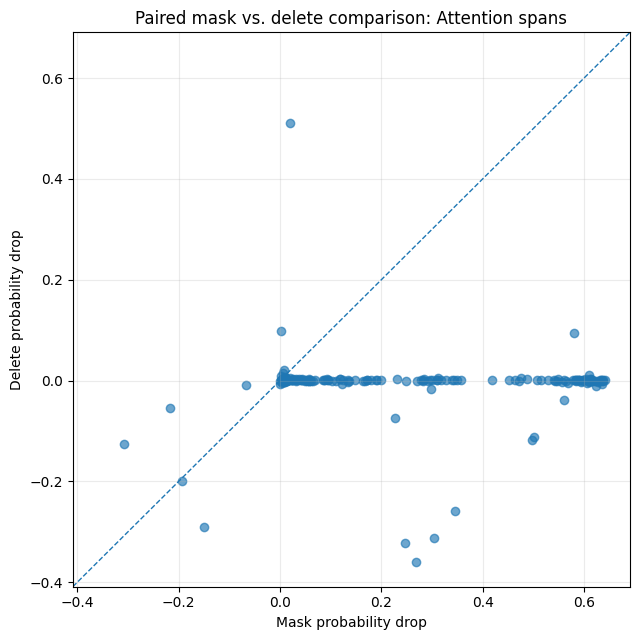

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/paired_scatter_shap_spans.png


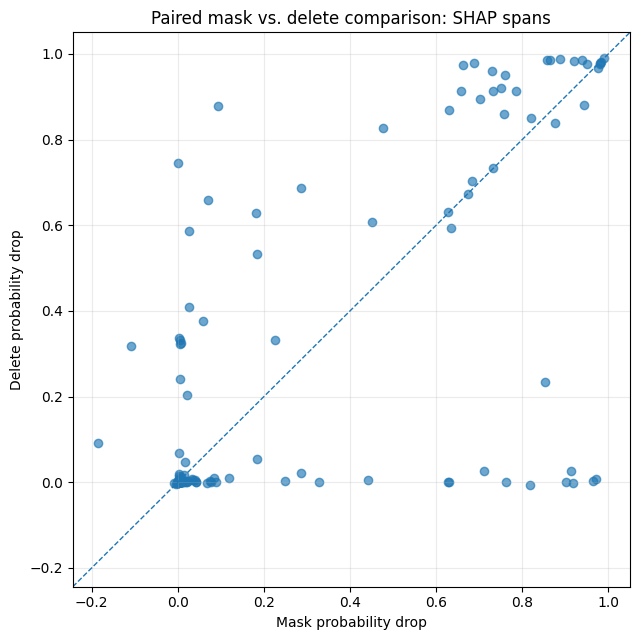

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/paired_scatter_mil_spans.png


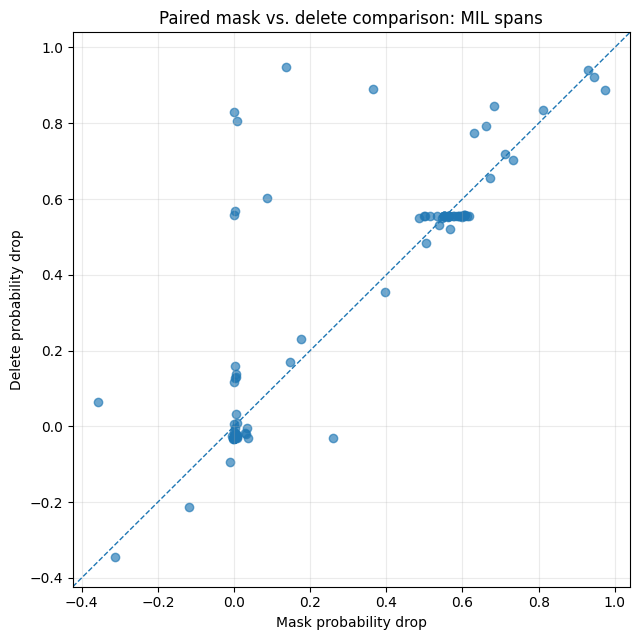

In [135]:
# Plot 4: Paired mask-vs-delete scatter plot for each method.
for method in METHOD_ORDER:
    method_df = results_argument_level.loc[
        results_argument_level["method"].eq(method)
    ]

    pivot = method_df.pivot(
        index="global_row_id",
        columns="ablation_mode",
        values="prob_drop",
    ).dropna(subset=["mask", "delete"])

    if pivot.empty:
        print(f"Skipping paired scatter for {method}: no paired rows.")
        continue

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.scatter(pivot["mask"], pivot["delete"], alpha=0.65)

    lower = float(np.nanmin(pivot[["mask", "delete"]].to_numpy()))
    upper = float(np.nanmax(pivot[["mask", "delete"]].to_numpy()))
    padding = max((upper - lower) * 0.05, 0.01)
    line_limits = [lower - padding, upper + padding]

    ax.plot(line_limits, line_limits, linestyle="--", linewidth=1)
    ax.set_xlim(line_limits)
    ax.set_ylim(line_limits)
    ax.set_xlabel("Mask probability drop")
    ax.set_ylabel("Delete probability drop")
    ax.set_title(f"Paired mask vs. delete comparison: {method}")
    ax.grid(alpha=0.25)

    save_current_figure(
        f"paired_scatter_{method.lower().replace(' ', '_')}.png"
    )
    plt.show()

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/paired_difference_histogram_random_spans.png


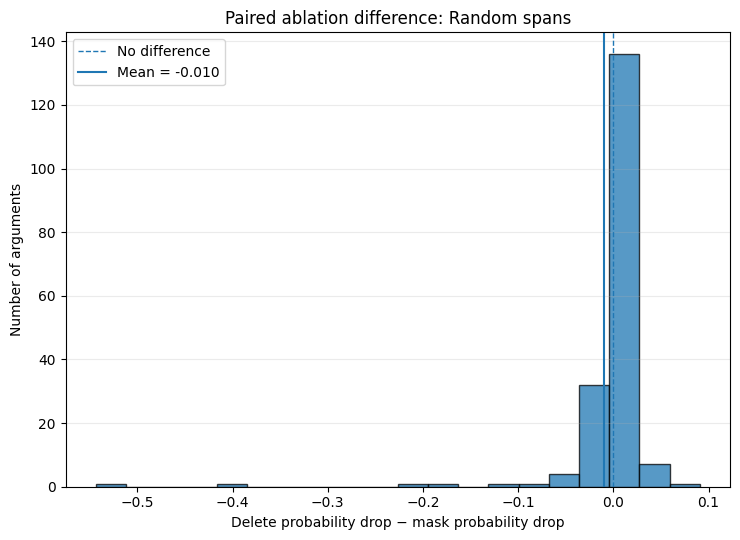

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/paired_difference_histogram_llm_spans.png


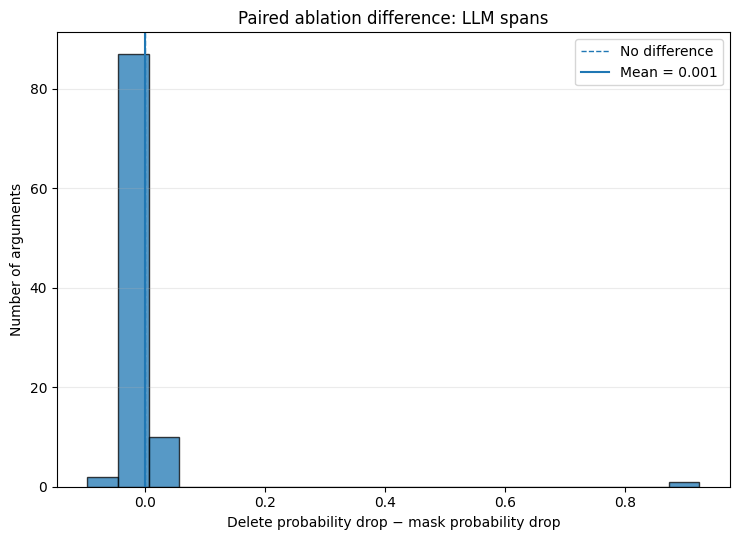

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/paired_difference_histogram_attention_spans.png


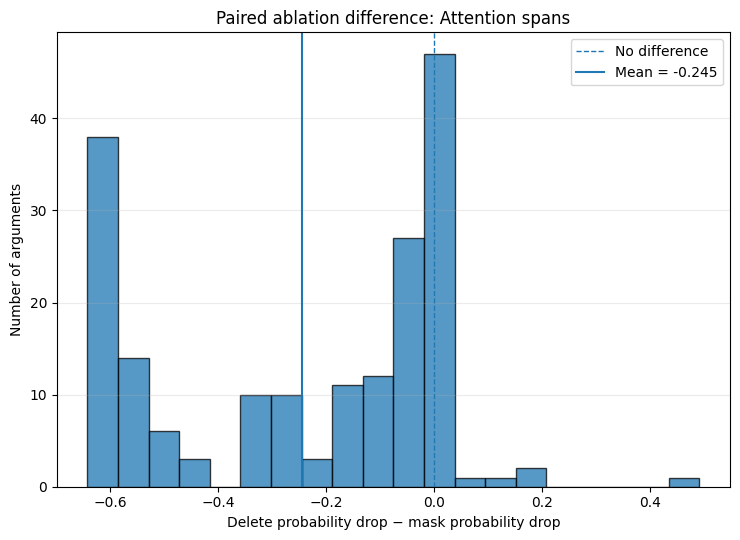

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/paired_difference_histogram_shap_spans.png


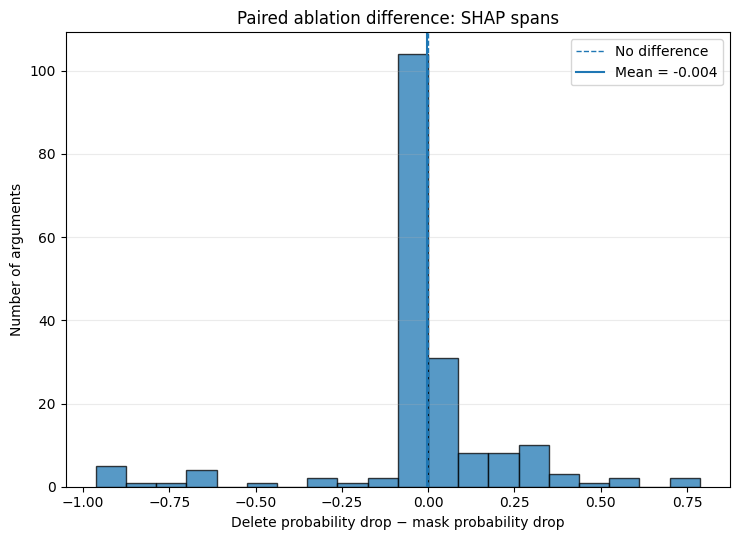

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/paired_difference_histogram_mil_spans.png


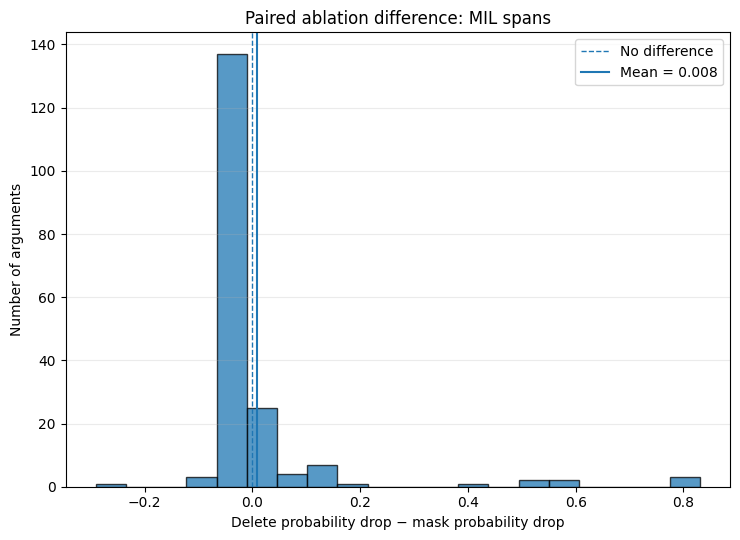

In [136]:
# Plot 5: Distribution of paired delete-minus-mask differences.
for method in METHOD_ORDER:
    method_df = results_argument_level.loc[
        results_argument_level["method"].eq(method)
    ]

    pivot = method_df.pivot(
        index="global_row_id",
        columns="ablation_mode",
        values="prob_drop",
    ).dropna(subset=["mask", "delete"])

    if pivot.empty:
        print(f"Skipping paired-difference histogram for {method}: no paired rows.")
        continue

    differences = pivot["delete"] - pivot["mask"]

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.hist(differences, bins=20, edgecolor="black", alpha=0.75)
    ax.axvline(0, linewidth=1, linestyle="--", label="No difference")
    ax.axvline(
        differences.mean(),
        linewidth=1.5,
        label=f"Mean = {differences.mean():.3f}",
    )

    ax.set_xlabel("Delete probability drop − mask probability drop")
    ax.set_ylabel("Number of arguments")
    ax.set_title(f"Paired ablation difference: {method}")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    save_current_figure(
        f"paired_difference_histogram_{method.lower().replace(' ', '_')}.png"
    )
    plt.show()

## 9. Optional comparison on common arguments only

This table restricts all five methods to the intersection of `global_row_id` values available in every method. It does not replace the within-method paired analysis; it provides a stricter descriptive comparison across methods on the same argument set.

In [137]:
common_argument_results = results_argument_level.loc[
    results_argument_level["global_row_id"].isin(common_ids)
].copy()

if len(common_ids) > 0:
    common_summary = (
        common_argument_results
        .groupby(["method", "ablation_mode"], sort=False)
        .apply(summarize_group)
        .reset_index()
    )
    display(common_summary.round(4))
else:
    common_summary = pd.DataFrame()
    print("No global_row_id values are shared across all five methods.")

,method,ablation_mode,n_arguments,mean_p_inappropriate_original,mean_p_inappropriate_perturbed,mean_prob_drop,std_prob_drop,median_prob_drop,q25_prob_drop,q75_prob_drop,mean_prob_drop_ci95_low,mean_prob_drop_ci95_high,positive_drop_rate,prediction_flip_rate,mean_selected_token_ratio,mean_deleted_char_ratio,mean_n_spans
0,Attention spans,delete,100.0,0.9874,0.9952,-0.0079,0.0551,0.0007,-0.0001,0.0018,-0.0204,0.0018,0.73,0.00,0.6005,0.5028,18.84
1,Attention spans,mask,100.0,0.9874,0.7341,0.2533,0.2448,0.1810,0.0150,0.5327,0.2040,0.3003,1.00,0.30,0.6005,0.5028,18.84
2,LLM spans,delete,100.0,0.9874,0.8605,0.1168,0.2879,-0.0098,-0.0102,-0.0076,0.0634,0.1745,0.64,0.17,0.2716,0.2708,1.96
3,LLM spans,mask,100.0,0.9874,0.8713,0.1160,0.2745,0.0002,-0.0001,0.0020,0.0650,0.1713,0.69,0.16,0.2716,0.2708,1.96
4,MIL spans,delete,100.0,0.9874,0.7897,0.1676,0.3166,-0.0295,-0.0301,0.5549,0.1063,0.2303,0.67,0.29,0.5439,0.5430,1.51
5,MIL spans,mask,100.0,0.9874,0.8240,0.1633,0.2926,0.0005,0.0000,0.4999,0.1079,0.2219,0.77,0.26,0.5439,0.5430,1.51
6,Random spans,delete,100.0,0.9874,0.8850,0.1024,0.2436,0.0003,-0.0001,0.0029,0.0583,0.1522,0.69,0.19,0.4839,0.4836,13.35
7,Random spans,mask,100.0,0.9874,0.8791,0.1083,0.2411,0.0007,0.0002,0.0111,0.0640,0.1591,0.79,0.20,0.4839,0.4836,13.35
8,SHAP spans,delete,100.0,0.9874,0.7833,0.2041,0.3654,0.0014,0.0001,0.2114,0.1357,0.2733,0.78,0.22,0.4198,0.4342,7.70
9,SHAP spans,mask,100.0,0.9874,0.7446,0.2428,0.3637,0.0075,0.0018,0.6285,0.1743,0.3151,0.96,0.28,0.4198,0.4342,7.70


## 10. Save all result tables

The method-specific files retain the original columns and add the deletion outputs. Combined files are suitable for downstream evaluation and thesis tables.

In [138]:
random_export = random_scored.copy()
llm_export = llm_scored.copy()
attention_export = attention_scored.copy()
shap_export = shap_scored.copy()
mil_export = mil_scored.copy()

output_files = {
    "random_per_row": OUTPUT_DIR / "random_mask_vs_delete_per_row.csv",
    "llm_per_argument": OUTPUT_DIR / "llm_mask_vs_delete_per_argument.csv",
    "attention_per_argument": OUTPUT_DIR / "attention_mask_vs_delete_per_argument.csv",
    "shap_per_argument": OUTPUT_DIR / "shap_mask_vs_delete_per_argument.csv",
    "mil_per_argument": OUTPUT_DIR / "mil_mask_vs_delete_per_argument.csv",
    "combined_long_raw": OUTPUT_DIR / "mask_vs_delete_long_row_level.csv",
    "combined_argument_level": OUTPUT_DIR / "mask_vs_delete_argument_level.csv",
    "summary_argument_level": OUTPUT_DIR / "mask_vs_delete_summary_argument_level.csv",
    "paired_statistics": OUTPUT_DIR / "mask_vs_delete_paired_statistics.csv",
    "sanity_checks": OUTPUT_DIR / "mask_vs_delete_sanity_checks.csv",
    "input_mode_validation": OUTPUT_DIR / "model_input_mode_validation.csv",
    "span_validation": OUTPUT_DIR / "mask_vs_delete_span_validation.csv",
}

random_export.to_csv(output_files["random_per_row"], index=False)
llm_export.to_csv(output_files["llm_per_argument"], index=False)
attention_export.to_csv(output_files["attention_per_argument"], index=False)
shap_export.to_csv(output_files["shap_per_argument"], index=False)
mil_export.to_csv(output_files["mil_per_argument"], index=False)

results_long_raw.to_csv(output_files["combined_long_raw"], index=False)
results_argument_level.to_csv(output_files["combined_argument_level"], index=False)
summary_argument_level.to_csv(output_files["summary_argument_level"], index=False)
paired_summary.to_csv(output_files["paired_statistics"], index=False)
sanity_table.to_csv(output_files["sanity_checks"], index=False)
mode_results.to_csv(output_files["input_mode_validation"], index=False)
span_validation.to_csv(output_files["span_validation"], index=False)

if not common_summary.empty:
    common_summary.to_csv(
        OUTPUT_DIR / "mask_vs_delete_common_arguments_summary.csv",
        index=False,
    )

print("Saved output files:")
for name, path in output_files.items():
    print(f"- {name}: {path}")

Saved output files:
- random_per_row: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/random_mask_vs_delete_per_row.csv
- llm_per_argument: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/llm_mask_vs_delete_per_argument.csv
- attention_per_argument: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/attention_mask_vs_delete_per_argument.csv
- shap_per_argument: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/shap_mask_vs_delete_per_argument.csv
- mil_per_argument: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/mil_mask_vs_delete_per_argument.csv
- combined_long_raw: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/mask_vs_delete_long_row_level.csv
- combined_argument_level: /Users/karsten/Workspace/Localizing-In

## Interpretation guide

Use the outputs in the following order:

1. **Check the span-validation table.** The three learned methods should no longer appear as having no valid spans simply because LLM offset columns are absent.
2. **Check input-mode reproduction.** If stored masking probabilities are not closely reproduced, fix the model configuration before interpreting deletion.
3. **Compare mean and median probability drop.** A larger positive value indicates a stronger reduction in the inappropriate-class probability.
4. **Inspect positive-drop rate.** This shows how consistently the ablation behaves in the intended direction.
5. **Use the paired difference.** `mean_delete_minus_mask > 0` favors deletion; a value below zero favors masking.
6. **Inspect the scatter plots and difference histograms.** They reveal whether an average advantage is broad or driven by a few outliers.
7. **Use the common-argument summary for cross-method comparisons.** This keeps the evaluated arguments identical across all five span sources.
8. **Do not remove empty deleted texts automatically.** They represent cases in which the selected content covers the complete argument and are therefore legitimate outcomes of the deletion operation.
9. **Do not choose an ablation solely because it causes the largest drop.** The final choice should combine effect magnitude, directional consistency, and the methodological consequences of each perturbation operator.

For thesis reporting, the argument-level summary and paired statistics are preferable to row-level random-sample statistics.